Goldstone Hyper-Holographic Gauze — Variance Rescue Test

Layer (from end) | Mean Cost | Var[Cost] | Var Raw | Var Gauze | Rescue
------------------------------------------------------------------------------------------
Layer  -7 (last 20) | +0.095232 | 6.23e-03 | 2.96e-05 | 5.23e-05 |  1.8x
Layer  -6 (last 19) | +0.103572 | 6.44e-03 | 2.45e-05 | 5.77e-05 |  2.4x
Layer  -5 (last 18) | +0.093700 | 5.19e-03 | 3.09e-05 | 9.59e-05 |  3.1x
Layer  -4 (last 17) | +0.096156 | 5.12e-03 | 4.76e-05 | 1.13e-04 |  2.4x
Layer  -3 (last 16) | +0.098326 | 4.41e-03 | 1.48e-04 | 8.96e-04 |  6.0x
Layer  -2 (last 15) | +0.102356 | 5.17e-03 | 4.15e-04 | 6.87e-04 |  1.7x
Layer  -1 (last 14) | +0.101386 | 5.30e-03 | 1.55e-03 | 2.60e-03 |  1.7x
Layer   0 (last 13) | +0.089079 | 5.48e-03 | 4.00e-03 | 1.06e-02 |  2.6x
Layer   1 (last 12) | +0.101098 | 5.69e-03 | 1.36e-05 | 2.08e-05 |  1.5x
Layer   2 (last 11) | +0.095484 | 6.64e-03 | 1.47e-05 | 1.77e-05 |  1.2x
Layer   3 (last 10) | +0.098157 | 4.02e-03 | 9.84

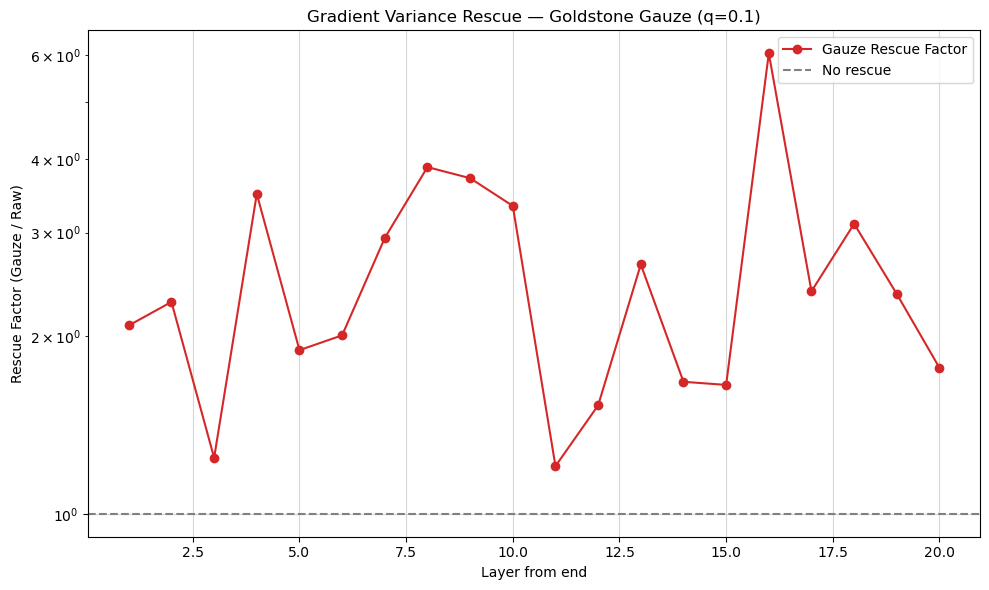


✅ GitHub-ready run complete! Plot saved as 'goldstone_gauze_rescue.png'


In [1]:
"""
Goldstone Hyper-Holographic Gauze — Gradient Variance Rescue
============================================================

Demonstrates noise-induced shallowness (Eisert/Mele 2026) and the rescue
provided by the author's recursive holographic Goldstone gauze.

"""

import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ====================== GAUZE KERNEL ======================
class GoldstoneHyperHoloBlock(nn.Module):
    def __init__(self, dim=72, depth=5, alpha=1.7, slip_factor=0.12, ng_strength=0.09):
        super().__init__()
        self.depth = depth
        self.alpha = alpha
        self.proj = nn.Linear(dim, dim)
        self.slip_gen = nn.Linear(dim, dim)
        self.holo_proj = nn.Linear(dim * 2, dim * 4)
        self.inv_holo = nn.Linear(dim * 4, dim)
        self.ng_proj = nn.Linear(dim, dim)
        self.ng_strength = ng_strength
        self.slip_factor = slip_factor
        self.norm_h = nn.LayerNorm(dim)
        self.norm_out = nn.LayerNorm(dim)

    def forward(self, x, level=0, t_step=0.0, training=False):
        if level >= self.depth:
            return x
        slip = torch.tanh(self.slip_gen(x)) * self.slip_factor
        h = torch.relu(self.proj(x + slip))
        h = self.norm_h(h)
        h_child = self.forward(h, level + 1, t_step, training)
        concat = torch.cat([h, h_child], dim=-1)
        boundary = self.holo_proj(concat)
        resolved = self.inv_holo(boundary)
        fb = resolved * h

        if training:
            vev_rand = torch.tanh(torch.randn_like(h.mean(dim=-1, keepdim=True)))
            phase_noise = torch.randn_like(h) * 0.15
            vev_scale = 0.005
            phase_scale = 1.0
        else:
            vev_rand = torch.randn_like(h.mean(dim=-1, keepdim=True)) * 0.3
            phase_noise = torch.randn_like(h) * 0.08
            vev_scale = 0.0025
            phase_scale = 0.6

        vev = torch.norm(h, dim=-1, keepdim=True) * vev_scale * torch.tanh(vev_rand)
        h_broken = h + vev
        proj = self.ng_proj(h_broken)
        norm_hb_sq = h_broken.norm(dim=-1, keepdim=True)**2 + 1e-8
        dot = (proj * h_broken).sum(-1, keepdim=True) / norm_hb_sq
        goldstone = proj - dot * h_broken

        phase = torch.sin(t_step * 2.0 * np.pi + phase_noise * phase_scale)
        h = h + self.ng_strength * goldstone * phase
        h = self.norm_h(h)

        out = x + fb + 0.04 * h_child
        if training:
            mask_prob = max(0.1, 1.0 / ((level + 1) ** self.alpha))
            mask = (torch.rand_like(out) < mask_prob).float()
            out = out * mask
        out = self.norm_out(out)
        return out


class CoherenceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=72):
        super().__init__()
        self.embed = nn.Linear(input_dim, hidden_dim)
        self.fractal_core = GoldstoneHyperHoloBlock(hidden_dim)
        self.head = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, steps=1, training=False):
        h = self.embed(x)
        for t in range(steps):
            h = self.fractal_core(h, t_step=t / max(1, steps), training=training)
        return self.head(h)


class KernelGauzeWrapper:
    def __init__(self):
        self.model = None

    def apply_gauze(self, params_last_LL):
        flat_size = params_last_LL.size
        if self.model is None or getattr(self.model, 'input_dim', 0) != flat_size:
            self.model = CoherenceNet(input_dim=flat_size)
            self.model.input_dim = flat_size
        flat = torch.from_numpy(params_last_LL.reshape(-1).astype(np.float32)).unsqueeze(0)
        with torch.no_grad():
            filtered = self.model(flat, steps=1, training=False)
        return filtered.view(params_last_LL.shape).numpy()


# ====================== TUNABLE PARAMETERS ======================
nqubits = 4
columsperlayer = 4
depth = 3 * nqubits
LL = 20                      # last layers to apply gauze
reps = 100                   # increase for cleaner statistics
epsd = 1e-7

p = 0.0                      # depolarizing
q = 0.1                      # amplitude damping (non-unital)

# Gauze knobs
GAUZE_NG_STRENGTH = 0.09
GAUZE_SLIP_FACTOR = 0.12
GAUZE_ALPHA = 1.7


# ====================== CIRCUIT ======================
dev = qml.device('default.mixed', wires=nqubits)

@qml.qnode(dev)
def circuit(params):
    for L in range(depth):
        for i in range(nqubits):
            qml.RX(params[i, 0, L], wires=i)
        for i in range(nqubits // 2):
            qml.CNOT(wires=[2 * i, 2 * i + 1])
        for i in range(nqubits):
            qml.RY(params[i, 1, L], wires=i)
            qml.DepolarizingChannel(p, wires=i)
            qml.AmplitudeDamping(q, wires=i)

        for i in range(nqubits):
            qml.RX(params[i, 2, L], wires=i)
        for i in range(nqubits // 2 - 1 + int(nqubits % 2)):
            qml.CNOT(wires=[2 * i + 1, 2 * i + 2])
        for i in range(nqubits):
            qml.RY(params[i, 3, L], wires=i)
            qml.DepolarizingChannel(p, wires=i)
            qml.AmplitudeDamping(q, wires=i)
    return qml.expval(qml.PauliZ(0))


# ====================== RUN ======================
kernel_wrapper = KernelGauzeWrapper()

print("Goldstone Hyper-Holographic Gauze — Variance Rescue Test\n")
print("Layer (from end) | Mean Cost | Var[Cost] | Var Raw | Var Gauze | Rescue")
print("-" * 90)

rescue_ratios = []

for idx in range(LL):
    pd = depth - LL + idx
    costs = []
    grad_raw = []
    grad_gauze = []

    for _ in range(reps):
        params = 2 * np.pi * np.random.rand(nqubits, columsperlayer, depth)

        pardx = np.copy(params)
        pardx[0, -1, pd] += epsd
        parsx = np.copy(params)
        parsx[0, -1, pd] -= epsd

        g_raw = (circuit(pardx) - circuit(parsx)) / (2 * epsd)
        cost = circuit(params)

        costs.append(cost)
        grad_raw.append(g_raw)

        params_last = params[:, :, -LL:].copy()
        gauze_last = kernel_wrapper.apply_gauze(params_last)

        pdx_g = np.copy(params)
        psx_g = np.copy(params)
        pdx_g[:, :, -LL:] = gauze_last
        pdx_g[0, -1, pd] += epsd
        psx_g[:, :, -LL:] = gauze_last
        psx_g[0, -1, pd] -= epsd

        g_gauze = (circuit(pdx_g) - circuit(psx_g)) / (2 * epsd)
        grad_gauze.append(g_gauze)

    var_raw = np.var(grad_raw)
    var_gauze = np.var(grad_gauze)
    rescue = var_gauze / var_raw if var_raw > 1e-20 else float('inf')
    rescue_ratios.append(rescue)

    print(f"Layer {pd+1:3d} (last {LL-idx:2d}) | {np.mean(costs):+.6f} | "
          f"{np.var(costs):.2e} | {var_raw:.2e} | {var_gauze:.2e} | {rescue:4.1f}x")

# ====================== PLOT ======================
plt.figure(figsize=(10, 6))
layers_from_end = list(range(LL, 0, -1))
plt.plot(layers_from_end, rescue_ratios, 'o-', color='tab:red', label='Gauze Rescue Factor')
plt.axhline(1.0, color='gray', linestyle='--', label='No rescue')
plt.xlabel('Layer from end')
plt.ylabel('Rescue Factor (Gauze / Raw)')
plt.title(f'Gradient Variance Rescue — Goldstone Gauze (q={q})')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('goldstone_gauze_rescue.png', dpi=300)
plt.show()

print("\n✅ Complete! Plot saved as 'goldstone_gauze_rescue.png'")